## Tylko testy do większych zbiorów danych

In [70]:
import torch

In [71]:
import os
import pandas as pd
from torchvision.io import read_image
import re
import wfdb
import wfdb.processing
import scipy
from torch.utils.data import Dataset
import numpy as np
import json
import torch.nn as nn
import torch
from tqdm import tqdm
import torch.nn.functional as F
import pickle

In [13]:
import os
import re
import numpy as np
import torch
from torch.utils.data import Dataset
import wfdb
import wfdb.processing
import scipy.signal

def extract_qrs_segment(signal, qrs_index, N):
    """
    Ekstrahuje segment sygnału EKG wokół zadanego indeksu QRS.
    Dopełnia brakujące próbki medianą sygnału, jeśli QRS jest blisko granic.
    """
    start_idx = qrs_index - N
    end_idx = qrs_index + N + 1  # +1, bo Python używa wykluczającego zakresu
    
    if start_idx < 0:
        padding_left = np.median(signal[:end_idx])
        segment = np.concatenate([np.full(-start_idx, padding_left), signal[:end_idx]])
    elif end_idx > len(signal):
        padding_right = np.median(signal[start_idx:])
        segment = np.concatenate([signal[start_idx:], np.full(end_idx - len(signal), padding_right)])
    else:
        segment = signal[start_idx:end_idx]
    
    return segment

class SHDB_QRS(Dataset):
    def __init__(self, N, dataset_dir, fs=100, load=True):
        """
        N - liczba próbek przed i po załamku QRS w segmencie.
        dataset_dir - ścieżka do katalogu z danymi EKG.
        fs - docelowa częstotliwość próbkowania.
        """
        self.N = N
        self.fs = fs
        self.qrs_indices = []
        if not load:
            self.ecg_list = []
            exclusion_lst = ['030']
            # print('dupa')
            # exclusion_lst = []  # Lista plików do wykluczenia, jeśli potrzebna
            for n,file in enumerate(os.listdir(dataset_dir)):
                # print('siusiak')
                name = re.match(r'^(.*\d\d+)\.atr$', file)
                # if name:
                #     print(name.group(1))
                if name and name.group(1) in exclusion_lst:
                    print(f"Przetwarzanie: {name.group(1)}")
                    record = wfdb.rdsamp(f"{dataset_dir}{name.group(1)}")
                    # annotation = wfdb.rdann(f"{dataset_dir}{name.group(1)}", 'atr')
                    annotation = wfdb.rdann(f"{dataset_dir}{name.group(1)}", 'atr', return_label_elements=['symbol'])
                    signal = record[0][:, 0]
                    fs = record[1]["fs"]
            
                    
                    # print(len(resampled_annotations))
                    # for i in resampled_annotations:
                    #     print(i)
                    # Detekcja QRS (np. użycie XQRS lub anotacji)

                    xqrs = wfdb.processing.XQRS(sig=signal, fs=fs)
                    xqrs.detect()  # Wykrywanie QRS
                    self.qrs_indices.append(xqrs.qrs_inds)
                    # print(len(self.qrs_indices))
                    
                    labels = annotation.aux_note
                    segments = annotation.sample

                    filtered_labels = []
                    filtered_segments = []  # Start with the first segment boundary

                    for i, label in enumerate(labels):
                        if label.strip():
                            filtered_labels.append(label)
                            filtered_segments.append(segments[i])

                    annotation.aux_note = np.array(filtered_labels)
                    annotation.sample = np.array(filtered_segments)
                    rr = wfdb.processing.calc_rr(xqrs.qrs_inds, fs=fs, min_rr=None, max_rr=None, qrs_units='samples', rr_units='seconds')
                    self.ecg_list.append({"name": name.group(1),"rec" : signal, "ann" : annotation, "rr" : rr})
                # if n == 2:
                #     break
            self.samples_list = []
            self.label_list = []
            self.qrs_samples = []
            self.idx_AFIB = []
            self.idx_Normal = []
            self.rr_list = []
            self.rr_label_list = []
            # self.label = []
            self.number_AFIB = []
            self.number_Normal = []
            no_of_afib = 0
            no_of_normal = 0

            for n,dic in enumerate(self.ecg_list):
                print(dic["name"])
                self.label_list.append([])
                if(len(dic["ann"].sample)==1):
                    idx_next = len(dic["rec"])
                else:
                    idx_next = dic["ann"].sample[1]
                label_t = dic["ann"].aux_note[0]
                temp_aux = 0
                arr_ann = np.array(dic["ann"].sample)
                # print(arr_ann)
                for qrs_n,idx in enumerate(self.qrs_indices[n]):
                    if (qrs_n<N) or (idx<dic["ann"].sample[0]) or (qrs_n>(len(self.ecg_list[n]["rr"]) - N - 1)):
                        self.label_list[-1].append(1 if label_t=='(AFIB' else 0)
                        continue
                    # self.rr_list.append([dic['rr'][(qrs_n-N):(qrs_n+N)]])
                    # self.rr_label_list.append([])
                    # l = 0
                    # for lab_idx in range(qrs_n-20, qrs_n+20):
                    #     # x = lab_idx if lab_idx < dic["ann"].sample[-1] else 
                    #     # print(lab_idx)
                    #     notes = arr_ann < self.qrs_indices[n][lab_idx]
                    #     # print(notes)
                    #     self.rr_label_list[-1].append((1 if dic["ann"].aux_note[np.where(notes)[0][-1]] == "(AFIB" else 0) if notes.any() else 0)
                    #     l += 1

                    while(idx>=idx_next):
                        temp_aux += 1
                        if(temp_aux!=len(dic["ann"].sample)-1):
                            idx_next = dic["ann"].sample[temp_aux+1]
                        else:
                            idx_next = len(dic["rec"])
                        label_t = dic["ann"].aux_note[temp_aux]
                    if(label_t == '(AFIB'):
                        self.idx_AFIB.append(qrs_n)
                        self.number_AFIB.append(n)
                    else:
                        self.idx_Normal.append(qrs_n)
                        self.number_Normal.append(n)
                    if (label_t == '(AFIB'):
                        no_of_afib+=1
                        self.label_list[-1].append(1)
                    else:
                        no_of_normal+=1
                        self.label_list[-1].append(0)
            self.sampled_idx_normal = np.random.choice(len(self.number_Normal), size=len(self.number_AFIB), replace=True)
        else:
            with open('shdb.pkl', 'rb') as file:
                lst = pickle.load(file)
                self.ecg_list = lst[0]
                self.number_Normal = lst[1]
                self.sampled_idx_normal = lst[2]
                self.N = lst[3]
                self.number_AFIB = lst[4]
                self.idx_AFIB = lst[5]
                self.qrs_samples = lst[6]
                self.label_list = lst[7]

    def save(self):
        with open('shdb.pkl', 'wb') as file:
            pickle.dump([self.ecg_list,
            self.number_Normal,
            self.sampled_idx_normal,
            self.N,
            self.number_AFIB,
            self.idx_AFIB,
            self.qrs_samples, 
            self.label_list],file)


    def resample(self):
        self.sampled_idx_normal = np.random.choice(len(self.number_Normal), size=len(self.number_AFIB), replace=True)
                
    def __len__(self):
        return len(self.sampled_idx_normal) + len(self.idx_AFIB)-1

    def __getitem__(self, idx):
        if(idx<len(self.sampled_idx_normal)):
            sample = self.ecg_list[self.number_Normal[self.sampled_idx_normal[idx]]]["rr"] [self.idx_Normal[self.sampled_idx_normal[idx]]-self.N: self.idx_Normal[self.sampled_idx_normal[idx]]+self.N]
            sample = torch.Tensor(sample).unsqueeze(0)
            labels = self.label_list[self.number_Normal[self.sampled_idx_normal[idx]]][self.idx_Normal[self.sampled_idx_normal[idx]]-self.N: self.idx_Normal[self.sampled_idx_normal[idx]]+self.N]
            # labels = self.label_list[self.number_Normal[self.sampled_idx_normal[idx]]][self.idx_Normal[self.sampled_idx_normal[idx]]-self.N: self.idx_Normal[self.sampled_idx_normal[idx]]+self.N]
            return sample, labels
        else:
            idx = idx - len(self.sampled_idx_normal)
            sample = self.ecg_list[self.number_AFIB[idx]]["rr"] [self.idx_AFIB[idx]-self.N: self.idx_AFIB[idx]+self.N]
            sample = torch.Tensor(sample).unsqueeze(0)
            labels = self.label_list[self.number_AFIB[idx]][self.idx_AFIB[idx]-self.N: self.idx_AFIB[idx]+self.N]
            return sample, labels
    
    # def __len__(self):
    #     return len(self.rr_segments)

    # def __getitem__(self, idx):
    #     segment = torch.Tensor(self.rr_segments[idx]).unsqueeze(0)  # Dodaj wymiar kanału
    #     label = self.labels[idx]
    #     return segment, label

In [14]:
ds = SHDB_QRS(20,'/home/zosia/dnn/dnn_ecg/physionet.org/shdb-af-a-japanese-holter-ecg-database-of-atrial-fibrillation-1.0.0/',fs=100, load=False)

Przetwarzanie: 030
Learning initial signal parameters...
Found 8 beats during learning. Initializing using learned parameters
Running QRS detection...
QRS detection complete.
030


In [17]:
print(ds[245][0].size())

torch.Size([1, 40])


In [74]:
# import matplotlib.pyplot as plt
# plt.plot(ds.qrs_indices[:10], [1 for i in range(10)])
for i in ds.qrs_indices:
    print(i)
# print(ds.qrs_indices)

83
187
279
383
464
543
624
696
775
853
940
1031
1107
1183
1264
1344
1432
1514
1594
1674
1755
1836
1918
2002
2086
2167
2248
2329
2412
2493
2585
2668
2742
2817
2896
3014
3108
3193
3275
3361
3453
3550
3639
3732
3841
3923
4019
4104
4191
4267
4360
4446
4558
4650
4765
4887
4999
5086
5163
5244
5327
5410
5495
5593
5673
5756
5839
5920
6003
6092
6179
6275
6352
6438
6527
6621
6720
6819
6911
7004
7098
7192
7280
7378
7472
7559
7648
7737
7826
7909
7999
8074
8166
8271
8363
8458
8545
8646
8729
8828
8926
9035
9130
9232
9330
9416
9496
9587
9662
9753
9842
9946
10031
10110
10188
10291
10384
10464
10549
10635
10719
10801
10884
10970
11053
11138
11223
11307
11396
11480
11560
11644
11730
11807
11887
11967
12060
12142
12220
12297
12375
12455
12537
12629
12734
12818
12901
12981
13068
13154
13238
13313
13394
13474
13563
13650
13730
13813
13892
13974
14073
14148
14226
14310
14392
14472
14558
14642
14722
14815
14897
14980
15063
15142
15230
15330
15414
15489
15571
15654
15735
15822
15907
16003
16080
16168
16252
16

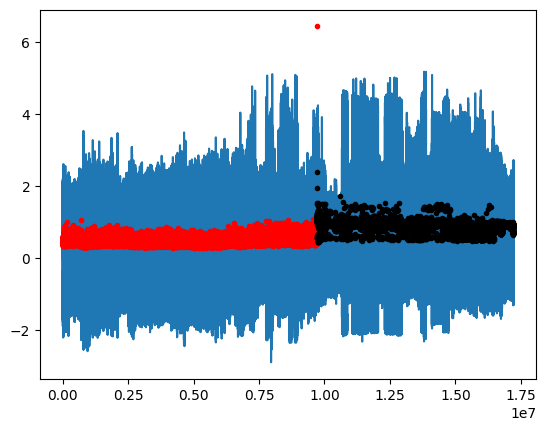

In [75]:
import matplotlib.pyplot as plt
plt.plot(ds.ecg_list[0]["rec"])
data = np.array([[ds.qrs_indices[ds.idx_AFIB[i]], ds.ecg_list[0]["rr"][ds.idx_AFIB[i]]] for i in range(len(ds.number_AFIB))])
plt.plot(data[:,0], data[:,1], '.r')
data = np.array([[ds.qrs_indices[ds.idx_Normal[i]], ds.ecg_list[0]["rr"][ds.idx_Normal[i]]] for i in range(len(ds.number_Normal))])
plt.plot(data[:,0], data[:,1], '.k')
# plt.xlim([14219592 - 3000,14219592 - 4000])

In [76]:
int(len(ds)/2-1)

102204

In [77]:
print(ds[102204-100])

(tensor([[0.9700, 0.9700, 0.9650, 0.9500, 0.9700, 0.9600, 0.9500, 0.9400, 0.9500,
         0.9450, 0.9300, 0.9550, 0.9550, 0.9450, 0.9400, 0.9300, 0.9600, 0.9550,
         0.9500, 0.9500, 0.9500, 0.9500, 0.9550, 0.9550, 0.9550, 0.9600, 0.9500,
         0.9550, 0.9500, 0.9450, 0.9450, 0.9300, 0.9300, 0.9300, 0.9150, 0.9250,
         0.9250, 0.8800, 0.9450, 0.9150]]), 0)


In [78]:
print(ds[0])

(tensor([[0.9200, 0.8000, 0.9200, 0.8000, 0.9250, 0.8000, 0.9200, 0.7850, 0.9100,
         0.7750, 0.9100, 0.7800, 0.9100, 0.7750, 0.8950, 0.7800, 0.9350, 0.8300,
         0.8500, 0.7700, 0.9350, 0.8200, 0.8150, 0.8000, 0.8650, 0.9000, 0.8750,
         0.8350, 0.8750, 0.8350, 0.8250, 0.8150, 0.7950, 0.7700, 0.7550, 0.7650,
         0.7600, 0.7700, 0.7500, 0.7400]]), 0)


In [79]:
from torch.utils.data import DataLoader, random_split

train_set, val_set = random_split(ds, [0.8, 0.2])
train = DataLoader(train_set, batch_size=32, shuffle=True)
val = DataLoader(val_set, batch_size=32, shuffle=True)

In [80]:
print(len(train_set))
print(train_set[102205][0])


163528
tensor([[0.3500, 0.4100, 0.4350, 0.3900, 0.3800, 0.4100, 0.4700, 0.3750, 0.3950,
         0.3750, 0.4100, 0.4200, 0.5150, 0.3950, 0.3700, 0.4550, 0.4600, 0.4750,
         0.3350, 0.3750, 0.3950, 0.3800, 0.3350, 0.5000, 0.4150, 0.3700, 0.3700,
         0.3800, 0.3950, 0.4550, 0.5900, 0.3900, 0.3550, 0.3900, 0.3400, 0.4200,
         0.4600, 0.4450, 0.4750, 0.4800]])


## Model a La resnet

In [81]:

from torchvision.io import read_image
import torch.nn as nn
import torch
from tqdm import tqdm

# class SimpleConv(nn.Module):
#     # def __init__(self, input = 41, input_ch = 1, num_classes = 2):
#     #     super(SimpleConv, self).__init__()
#     #     self.model = nn.Sequential(
#     #         nn.Conv1d(input_ch, 64, kernel_size=6, padding='same'),
#     #         nn.BatchNorm1d(64),
#     #         nn.ReLU(),
#     #         nn.Conv1d(64, 64, kernel_size=3, padding='same'),
#     #         nn.BatchNorm1d(64),
#     #         nn.ReLU(),
#     #         nn.Conv1d(64, 128, kernel_size=3, padding='same'),      # out 1 x 128 x n
#     #         nn.BatchNorm1d(128),
#     #         nn.ReLU(),
#     #         nn.MaxPool1d(2),                        # out 1 x 128 x n//2
#     #         nn.Conv1d(128, 128, kernel_size=3, padding='same'),
#     #         nn.BatchNorm1d(128),
#     #         nn.ReLU(),
#     #         nn.Conv1d(128, 256, kernel_size=3, padding='same'),     # out 1 x 256 x n//2
#     #         nn.BatchNorm1d(256),
#     #         nn.ReLU(),
#     #         nn.MaxPool1d(2),                        # out 1 x 256 x n//4
#     #         nn.Conv1d(256, 256, kernel_size=3, padding='same'),     
#     #         nn.BatchNorm1d(256),
#     #         nn.ReLU(),
#     #         nn.Conv1d(256, 512, kernel_size=3, padding='same'),     
#     #         nn.BatchNorm1d(512),
#     #         nn.ReLU(),
#     #         nn.MaxPool1d(2),                        # out 1 x 512 x n//8
#     #         nn.Flatten(),
#     #         nn.Linear(512*(input//8), 256),
#     #         nn.Dropout(0.5),
#     #         nn.Linear(256, num_classes),
#     #     )
#     #     self.model.to('cuda:0')
#     # def __init__(self, input = 41, input_ch = 1, num_classes = 2):
#     #     super(SimpleConv, self).__init__()
#     #     self.model = nn.Sequential(
#     #         nn.Conv1d(input_ch, 64, kernel_size=6, padding='same'),
#     #         nn.BatchNorm1d(64),
#     #         nn.ReLU(),
#     #         nn.Conv1d(64, 64, kernel_size=3, padding='same'),
#     #         nn.BatchNorm1d(64),
#     #         nn.ReLU(),
#     #         nn.Conv1d(64, 128, kernel_size=3, padding='same'),      # out 1 x 128 x n
#     #         nn.BatchNorm1d(128),
#     #         nn.ReLU(),
#     #         nn.MaxPool1d(2),                        # out 1 x 128 x n//2
#     #         nn.Conv1d(128, 128, kernel_size=3, padding='same'),
#     #         nn.BatchNorm1d(128),
#     #         nn.ReLU(),
#     #         nn.Conv1d(128, 256, kernel_size=3, padding='same'),     # out 1 x 256 x n//2
#     #         nn.BatchNorm1d(256),
#     #         nn.ReLU(),
#     #         nn.MaxPool1d(2),                        # out 1 x 256 x n//4
#     #         nn.Conv1d(256, 256, kernel_size=3, padding='same'),     
#     #         nn.BatchNorm1d(256),
#     #         nn.ReLU(),
#     #         nn.Conv1d(256, 512, kernel_size=3, padding='same'),     
#     #         nn.BatchNorm1d(512),
#     #         nn.ReLU(),
#     #         nn.MaxPool1d(2),                        # out 1 x 512 x n//8
#     #         nn.Flatten(),
#     #         nn.Linear(512*2, 256),  # Poprawiony wymiar wejścia do Linear
#     #         nn.Dropout(0.5),
#     #         nn.Linear(256, num_classes),
#     #     )
#         # self.model.to('cuda:0')
#     def __init__(self, input=41, input_ch=1, num_classes=2):
#         super(SimpleConv, self).__init__()
#         self.model = nn.Sequential(
#             nn.Conv1d(input_ch, 64, kernel_size=6, padding='same'),
#             nn.BatchNorm1d(64),
#             nn.ReLU(),
#             nn.Conv1d(64, 64, kernel_size=3, padding='same'),
#             nn.BatchNorm1d(64),
#             nn.ReLU(),
#             nn.Conv1d(64, 128, kernel_size=3, padding='same'),
#             nn.BatchNorm1d(128),
#             nn.ReLU(),
#             nn.MaxPool1d(2),
#             nn.Conv1d(128, 128, kernel_size=3, padding='same'),
#             nn.BatchNorm1d(128),
#             nn.ReLU(),
#             nn.Conv1d(128, 256, kernel_size=3, padding='same'),
#             nn.BatchNorm1d(256),
#             nn.ReLU(),
#             nn.MaxPool1d(2),
#             nn.Conv1d(256, 256, kernel_size=3, padding='same'),
#             nn.BatchNorm1d(256),
#             nn.ReLU(),
#             nn.Conv1d(256, 512, kernel_size=3, padding='same'),
#             nn.BatchNorm1d(512),
#             nn.ReLU(),
#             nn.MaxPool1d(2),
#             nn.Flatten(),
#             # Zmieniamy ten wymiar na odpowiedni
#             nn.Linear(512 * 5, 256),  # Zakładając, że długość wejściowa to 40, wynikowy wymiar to 512 * 5
#             nn.Dropout(0.5),
#             nn.Linear(256, num_classes),
#         )
#         self.model.to('cuda:0')

#     # def forward(self, x):

#     #     return self.model(x)
#     def forward(self, x):
#         # for layer in self.model:
#         #     x = layer(x)
#         #     print(f"Output shape after {layer}: {x.shape}")
#         # return x
#         # print(f"Input shape: {x.shape}")  # Zobacz, jaki jest wymiar wejściowy
#         # x = self.model[0](x)  # Conv1d
#         # print(f"After Conv1d: {x.shape}")
#         # x = self.model[1](x)  # BatchNorm1d
#         # x = self.model[2](x)  # ReLU
#         # x = self.model[3](x)  # Conv1d
#         # print(f"After second Conv1d: {x.shape}")
#         # x = self.model[4](x)  # BatchNorm1d
#         # x = self.model[5](x)  # ReLU
#         # x = self.model[6](x)  # Conv1d
#         # print(f"After third Conv1d: {x.shape}")
#         # x = self.model[7](x)  # BatchNorm1d
#         # x = self.model[8](x)  # ReLU
#         # x = self.model[9](x)  # MaxPool1d
#         # print(f"After MaxPool1d: {x.shape}")
#         # x = self.model[10](x)  # Conv1d
#         # print(f"After fourth Conv1d: {x.shape}")
#         # x = self.model[11](x)  # BatchNorm1d
#         # x = self.model[12](x)  # ReLU
#         # x = self.model[13](x)  # Conv1d
#         # print(f"After fifth Conv1d: {x.shape}")
#         # x = self.model[14](x)  # BatchNorm1d
#         # x = self.model[15](x)  # ReLU
#         # x = self.model[16](x)  # MaxPool1d
#         # print(f"After second MaxPool1d: {x.shape}")
#         # x = self.model[17](x)  # Flatten
#         # print(f"After Flatten: {x.shape}")
#         # x = self.model[18](x)  # Linear
#         # print(f"After Linear: {x.shape}")
#         # return x
#         print(f"Input shape: {x.shape}")
#         x = self.model[0](x)  # Conv1d
#         print(f"After Conv1d: {x.shape}")
#         x = self.model[1](x)  # BatchNorm1d
#         x = self.model[2](x)  # ReLU
#         x = self.model[3](x)  # Conv1d
#         print(f"After second Conv1d: {x.shape}")
#         x = self.model[4](x)  # BatchNorm1d
#         x = self.model[5](x)  # ReLU
#         x = self.model[6](x)  # Conv1d
#         print(f"After third Conv1d: {x.shape}")
#         x = self.model[7](x)  # BatchNorm1d
#         x = self.model[8](x)  # ReLU
#         x = self.model[9](x)  # MaxPool1d
#         print(f"After MaxPool1d: {x.shape}")
#         x = self.model[10](x)  # Conv1d
#         print(f"After fourth Conv1d: {x.shape}")
#         x = self.model[11](x)  # BatchNorm1d
#         x = self.model[12](x)  # ReLU
#         x = self.model[13](x)  # Conv1d
#         print(f"After fifth Conv1d: {x.shape}")
#         x = self.model[14](x)  # BatchNorm1d
#         x = self.model[15](x)  # ReLU
#         x = self.model[16](x)  # MaxPool1d
#         print(f"After second MaxPool1d: {x.shape}")
        
#         # Flattening the tensor properly:
#         x = x.view(x.size(0), -1)  # Flatten
#         print(f"After Flatten: {x.shape}")
        
#         x = self.model[18](x)  # Linear
#         print(f"After Linear: {x.shape}")
#         return x
class SimpleConv(nn.Module):
    def __init__(self, input=41, input_ch=1, num_classes=2):
        super(SimpleConv, self).__init__()
        self.model = nn.Sequential(
            nn.Conv1d(input_ch, 64, kernel_size=6, padding='same'),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Conv1d(64, 64, kernel_size=3, padding='same'),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Conv1d(64, 128, kernel_size=3, padding='same'),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(128, 128, kernel_size=3, padding='same'),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Conv1d(128, 256, kernel_size=3, padding='same'),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(256, 256, kernel_size=3, padding='same'),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Conv1d(256, 512, kernel_size=3, padding='same'),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Flatten(),
            # Zmieniamy ten wymiar na odpowiedni
            nn.Linear(512 * 5, 256),  # Zakładając, że długość wejściowa to 40, wynikowy wymiar to 512 * 5
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )
        self.model.to('cuda:0')

    def forward(self, x):
        print(f"Input shape: {x.shape}")
        x = self.model[0](x)  # Conv1d
        print(f"After Conv1d: {x.shape}")
        x = self.model[1](x)  # BatchNorm1d
        x = self.model[2](x)  # ReLU
        x = self.model[3](x)  # Conv1d
        print(f"After second Conv1d: {x.shape}")
        x = self.model[4](x)  # BatchNorm1d
        x = self.model[5](x)  # ReLU
        x = self.model[6](x)  # Conv1d
        print(f"After third Conv1d: {x.shape}")
        x = self.model[7](x)  # BatchNorm1d
        x = self.model[8](x)  # ReLU
        x = self.model[9](x)  # MaxPool1d
        print(f"After MaxPool1d: {x.shape}")
        x = self.model[10](x)  # Conv1d
        print(f"After fourth Conv1d: {x.shape}")
        x = self.model[11](x)  # BatchNorm1d
        x = self.model[12](x)  # ReLU
        x = self.model[13](x)  # Conv1d
        print(f"After fifth Conv1d: {x.shape}")
        x = self.model[14](x)  # BatchNorm1d
        x = self.model[15](x)  # ReLU
        x = self.model[16](x)  # MaxPool1d
        print(f"After second MaxPool1d: {x.shape}")
        
        # Flattening the tensor properly:
        x = x.view(x.size(0), -1)  # Flatten
        print(f"After Flatten: {x.shape}")
        
        x = self.model[18](x)  # Linear
        print(f"After Linear: {x.shape}")
        return x

    
    def train_model(self, train_loader, valid_loader, num_epochs = 5, learning_rate=0.001, save_best = True, save_thr = 0.94):
        best_accuracy = 0.0
        total_step = len(train_loader)
        # Loss and optimizer
        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.RMSprop(self.parameters(), lr=learning_rate, weight_decay = 0.005, momentum = 0.9)  

        for epoch in range(num_epochs):
            # self.train()
            correct = 0
            total = 0
            for i, (images, labels) in enumerate(tqdm(train_loader)):
                # print(f"Batch {i}: images shape = {images.shape}, labels shape = {labels.shape}")
                if images.size(0) == 0:  # Pominięcie pustego batcha
                    # print(f"Pominięto pusty batch w iteracji {i}")
                    continue
   
                # Move tensors to the configured device
                images = images.float().to("cuda")
                labels = labels.type(torch.LongTensor)
                labels = labels.to("cuda")


                optimizer.zero_grad()

                # Forward pass
                outputs = self.forward(images)
                loss = criterion(outputs, labels)
                # Backward and optimize
                loss.backward()
                
                optimizer.step()

                # accuracy
                _, predicted = torch.max(outputs.data, 1)
                correct += (torch.eq(predicted, labels)).sum().item()
                total += labels.size(0)

                del images, labels, outputs

            print ('Epoch [{}/{}], Step [{}/{}], Loss: {:.4f}, Accuracy: {:.4f}'
                            .format(epoch+1, num_epochs, i+1, total_step, loss.item(), (float(correct))/total))


            if torch.cuda.is_available():
                torch.cuda.empty_cache()

            # Validation
            with torch.no_grad():
                correct = 0
                total = 0
                for images, labels in valid_loader:
                    images = images.float().to("cuda")
                    labels = labels.to("cuda")
                    outputs = self.forward(images)
                    _, predicted = torch.max(outputs.data, 1)
                    total += labels.size(0)
                    correct += (torch.eq(predicted, labels)).sum().item()
                    del images, labels, outputs
                if(((100 * correct / total) > best_accuracy) and save_best and ((100 * correct / total) > save_thr)):
                    torch.save(self.state_dict(), "simp_conv_qrs.pt")

                print('Accuracy of the network: {} %'.format( 100 * correct / total))

In [82]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SimpleConv(nn.Module):
    def __init__(self, input_size=40, input_ch=1, num_classes=2):
        super(SimpleConv, self).__init__()

        # Uproszczona wersja modelu
        self.conv1 = nn.Conv1d(input_ch, 64, kernel_size=5, padding='same')
        self.bn1 = nn.BatchNorm1d(64)
        self.conv2 = nn.Conv1d(64, 128, kernel_size=3, padding='same')
        self.bn2 = nn.BatchNorm1d(128)
        self.pool = nn.MaxPool1d(2)

        # Obliczymy wymiar po warstwach Conv1d i MaxPool1d
        self.fc1_input_size = 128 * (input_size // 2)  # Po 2 max pooling
        self.fc1 = nn.Linear(self.fc1_input_size, 256)
        self.fc2 = nn.Linear(256, num_classes)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        # Pass through conv1
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)

        # Pass through conv2
        x = self.conv2(x)
        x = self.bn2(x)
        x = F.relu(x)

        # Max pooling
        x = self.pool(x)

        # Flatten the output for the fully connected layers
        x = torch.flatten(x, 1)

        # Fully connected layers
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)

        return x
    def train_model(self, train_loader, valid_loader, num_epochs = 5, learning_rate=0.001, save_best = True, save_thr = 0.94):
        best_accuracy = 0.0
        total_step = len(train_loader)
        # Loss and optimizer
        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.RMSprop(self.parameters(), lr=learning_rate, weight_decay = 0.005, momentum = 0.9)  

        for epoch in range(num_epochs):
            # self.train()
            correct = 0
            total = 0
            for i, (images, labels) in enumerate(tqdm(train_loader)):
                # print(f"Batch {i}: images shape = {images.shape}, labels shape = {labels.shape}")
                if images.size(0) == 0:  # Pominięcie pustego batcha
                    # print(f"Pominięto pusty batch w iteracji {i}")
                    continue
   
                # Move tensors to the configured device
                images = images.float().to("cuda")
                labels = labels.type(torch.LongTensor)
                labels = labels.to("cuda")


                optimizer.zero_grad()

                # Forward pass
                outputs = self.forward(images)
                loss = criterion(outputs, labels)
                # Backward and optimize
                loss.backward()
                
                optimizer.step()

                # accuracy
                _, predicted = torch.max(outputs.data, 1)
                correct += (torch.eq(predicted, labels)).sum().item()
                total += labels.size(0)

                del images, labels, outputs

            print ('Epoch [{}/{}], Step [{}/{}], Loss: {:.4f}, Accuracy: {:.4f}'
                            .format(epoch+1, num_epochs, i+1, total_step, loss.item(), (float(correct))/total))


            if torch.cuda.is_available():
                torch.cuda.empty_cache()

            # Validation
            with torch.no_grad():
                correct = 0
                total = 0
                for images, labels in valid_loader:
                    images = images.float().to("cuda")
                    labels = labels.to("cuda")
                    outputs = self.forward(images)
                    _, predicted = torch.max(outputs.data, 1)
                    total += labels.size(0)
                    correct += (torch.eq(predicted, labels)).sum().item()
                    del images, labels, outputs
                if(((100 * correct / total) > best_accuracy) and save_best and ((100 * correct / total) > save_thr)):
                    torch.save(self.state_dict(), "simp_conv_qrs.pt")

                print('Accuracy of the network: {} %'.format( 100 * correct / total))

In [83]:
# model_res.train_model(train,val,num_epochs=90,learning_rate=0.0001,save_best=True)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SimpleConv().to(device)
model.train_model(train,val,num_epochs=6, save_best=True)

100%|██████████| 5111/5111 [00:11<00:00, 434.34it/s]


Epoch [1/6], Step [5111/5111], Loss: 0.0004, Accuracy: 0.9966
Accuracy of the network: 97.32889780343427 %


100%|██████████| 5111/5111 [00:10<00:00, 468.69it/s]


Epoch [2/6], Step [5111/5111], Loss: 0.0017, Accuracy: 0.9970
Accuracy of the network: 99.86546646445869 %


100%|██████████| 5111/5111 [00:10<00:00, 470.58it/s]


...

Epoch [4/6], Step [5111/5111], Loss: 0.0004, Accuracy: 0.9975
Accuracy of the network: 99.86791252874126 %


100%|██████████| 5111/5111 [00:10<00:00, 470.97it/s]


Epoch [5/6], Step [5111/5111], Loss: 0.0507, Accuracy: 0.9974
Accuracy of the network: 98.95308448706032 %


100%|██████████| 5111/5111 [00:10<00:00, 467.73it/s]


Epoch [6/6], Step [5111/5111], Loss: 0.0003, Accuracy: 0.9974
Accuracy of the network: 99.89971136441466 %


In [84]:
model.to('cpu')
torch.save(model.state_dict(), "simp_conv_qrs.pt")